## Preparation

### Requirements

In [1]:
%pip install torchinfo torchvision opencv-python matplotlib kagglehub seaborn

Note: you may need to restart the kernel to use updated packages.


### Dataset preparation

This step downloads the dataset from Kaggle, and prepares it to be used. It splits the dataset into training, validation, and test sets, and prepares the directory structure for the dataloaders:
 * `data/train/[class]`
 * `data/test/[class]`
 * `data/val/[class]`

#### Downloading

In [2]:
import kagglehub

# https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset", output_dir="./data")

/home/pol/Downloads/AIH/Assignment/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Splitting

In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

import os
import shutil
from sklearn.model_selection import train_test_split

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

def split_dataset(source_dir, output_dir, classes=("Normal", "Tuberculosis"),
                  train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):

    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith((".png"))]

        train_files, temp_files = train_test_split(image_files, train_size=train_size, random_state=random_state,shuffle=True)
        val_relative_size = val_size / (val_size + test_size) # de les que queden, dividim segons split
        val_files, test_files = train_test_split(temp_files, train_size=val_relative_size, random_state=random_state, shuffle=True)

        # mètode per copiar d'un dir a un altre
        def copy_files(files, split):
            target_dir = os.path.join(output_dir, split, cls)
            for file in files:
                shutil.copy2(os.path.join(class_dir, file), os.path.join(target_dir, file))

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

source_dir = "./data/TB_Chest_Radiography_Database"

split_dataset(
    source_dir=source_dir,
    output_dir="./data",
    train_size=TRAIN_SPLIT,
    val_size=VAL_SPLIT,
    test_size=TEST_SPLIT,
)

# eliminem per espai
shutil.rmtree(source_dir)

FileNotFoundError: [Errno 2] No such file or directory: './data/TB_Chest_Radiography_Database/Normal'

In [1]:
import utils
# import networks
import torch
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from plot_utils import plot_confmat, plot_gradcam
from grad_cam import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
from torchinfo import summary

## Dataset analysis

The idea of this step is to load the dataset and analyze it. We will look at the class distribution, and some sample images for each class.

### Sample image ploting

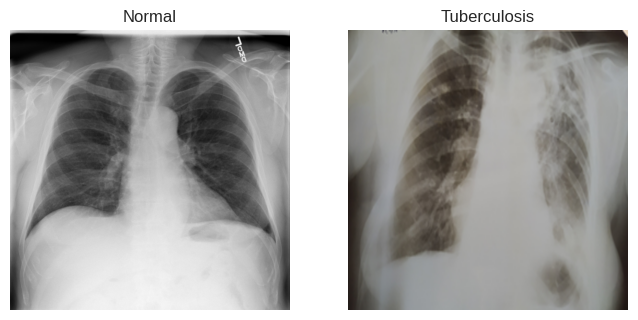

In [3]:
# Loading the data for visualization
test_set = datasets.ImageFolder(root=utils.dirs['test'], transform=transforms.ToTensor())
test_dl = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=True, num_workers=2)
images, labels = next(iter(test_dl)) # Load the first batch from the dataloader (size 16)

class_names = ['Normal', 'Tuberculosis']
class_samples = {class_name: None for class_name in class_names}

# Get a sample image for each one of the classes
for c in class_samples:
    idx_class = test_set.class_to_idx[c]
    idx_img = torch.where(labels == idx_class)[0][0].item()
    class_samples[c] = images[idx_img]
    
# Plot the samples
fig = plt.figure(figsize=(8, 8))
for i in np.arange(2):
    label = class_names[i]
    img = class_samples[label]
    ax = fig.add_subplot(2, 2, i+1)
    ax.axis('off')
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(label)
# fig.savefig('outputs/samples.png')

### Class distribution

Count for each class in the training set: {'Normal': 2450, 'Tuberculosis': 489}
Percentage for each class in the training set: {'Normal': 83.36, 'Tuberculosis': 16.64}%


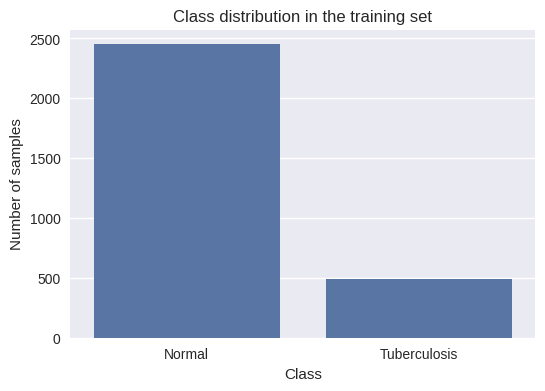

In [4]:
# plot class distribution in the training set
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=transforms.ToTensor())
train_dl = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
train_images, train_labels = next(iter(train_dl))
targets = train_set.targets
class_counts = [targets.count(i) for i in range(len(class_names))]
plt.figure(figsize=(6, 4))
sns.barplot(x=class_names, y=class_counts)
plt.title("Class distribution in the training set")
plt.ylabel("Number of samples")
plt.xlabel("Class")

print(f"Count for each class in the training set: {dict(zip(class_names, class_counts))}")
print(f"Percentage for each class in the training set: {dict(zip(class_names, [round(count / len(train_set) * 100, 2) for count in class_counts]))}%")

## Transfer learning

The idea of this step is to use two pretrained models (ResNet50 and EfficientNetB0) and fine-tune them on our dataset. We will then compare the results of the two models and choose the best one for the following steps.

In [5]:
BATCH_SIZE = 4

# we'll set up device used for training
device = utils.device
print(f"Using device: {device}")

# and prepare the train loader
train_set = datasets.ImageFolder(root=utils.dirs['train'], transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
train_images, train_labels = next(iter(train_loader))

Using device: cuda


In [ ]:
def train_model(model, train_loader, criterion, optimizer, num_epochs, save_path):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        current = 0

        for images, labels in train_loader:
            current += images.size(0)

            print(
                f"Epoch {epoch+1}/{num_epochs} - "
                f"Progress: {current}/{len(train_loader.dataset)}",
                end='\r'
            )

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_acc:.4f}"
        )

    # save model
    os.makedirs("models", exist_ok=True)

    torch.save(model.state_dict(), save_path)

    print(f"Model saved to {save_path}")

In [7]:
def evaluate_model(model, test_loader):
    test_preds = utils.get_all_preds(model, test_loader)
    test_correct = utils.get_num_correct(test_preds, torch.as_tensor(test_set.targets, device=device))
    print(f'Test Correct: {test_correct:6}\tTest Accuracy: {(100*test_correct/len(test_set)):6.2f}%')

    test_preds = test_preds.cpu()
    test_set.targets = torch.as_tensor(test_set.targets)
    test_confmat = utils.get_confmat(test_set, test_preds)
    plot_confmat(test_confmat, test_set.classes, f'{type(model).__name__.lower()}')

### ResNet50

In [17]:
# load resnet50 and train it
# load resetnet18

# resnet50 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
resnet50 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
resnet50.fc = torch.nn.Linear(resnet50.fc.in_features, len(class_names))

summary(resnet50)
# we can see how resnet50 has nearly 25M parameters

resnet50.to(device)

Using cache found in /home/pol/.cache/torch/hub/pytorch_vision_v0.10.0
/home/pol/Downloads/AIH/Assignment/.env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/pol/Downloads/AIH/Assignment/.env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
# criterion will be cross entropy loss since we have a classification problem
# optimizer will be Adam with a learning rate of 1e-4

import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    resnet50.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

NUM_EPOCHS = 5

train_model(resnet50, train_loader, criterion, optimizer, NUM_EPOCHS, "models/resnet50.pth")

Epoch [1/1] Loss: 0.1255 Accuracy: 0.9530


In [ ]:
test_preds = utils.get_all_preds(resnet50, test_dl)
test_correct = utils.get_num_correct(test_preds, torch.as_tensor(test_set.targets, device=device))
print(f'Test Correct: {test_correct:6}\tTest Accuracy: {(100*test_correct/len(test_set)):6.2f}%')


Test Correct:    431	Test Accuracy:  68.30%


<Figure size 1600x600 with 0 Axes>

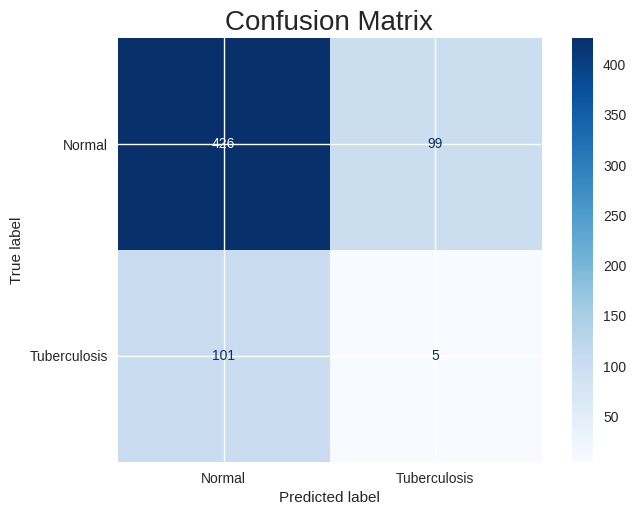

In [15]:
test_preds = test_preds.cpu()
test_set.targets = torch.as_tensor(test_set.targets)
test_confmat = utils.get_confmat(test_set, test_preds)
plot_confmat(test_confmat, test_set.classes, f'{type(resnet50).__name__.lower()}')

### EfficientNetB0

In [6]:
# load efficientnetb0 and train it
efficientnet = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_efficientnet_b0', pretrained=True)

# per veure com és la part de classificiació i veure quants inputs ha de tenir l'última capa per adaptar-la
# print(efficientnet.classifier) # veiem que té una última linear de 1000 outputs i 1280 inputs
efficientnet.classifier[-1] = torch.nn.Linear(efficientnet.classifier[-1].in_features, len(class_names))

summary(efficientnet)
efficientnet.to(device)

Using cache found in /home/pol/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/home/pol/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/pol/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(


EfficientNet(
  (stem): Sequential(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
    (activation): SiLU(inplace=True)
  )
  (layers): Sequential(
    (0): Sequential(
      (block0): MBConvBlock(
        (depsep): Sequential(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (se): SequentialSqueezeAndExcitation(
          (squeeze): Linear(in_features=32, out_features=8, bias=True)
          (expand): Linear(in_features=8, out_features=32, bias=True)
          (activation): SiLU(inplace=True)
          (sigmoid): Sigmoid()
          (mul_a_quantizer): Identity()
          (mul_b_quantizer): Ident

In [ ]:
# criterion will be cross entropy loss since we have a classification problem
# optimizer will be Adam with a learning rate of 1e-4

from sympy import N
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    efficientnet.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

NUM_EPOCHS = 5

train_model(efficientnet, train_loader, criterion, optimizer, NUM_EPOCHS, "models/efficientnet.pth")

Epoch [1/1] Loss: 0.1319 Accuracy: 0.9799


Test Correct:    462	Test Accuracy:  73.22%


<Figure size 1600x600 with 0 Axes>

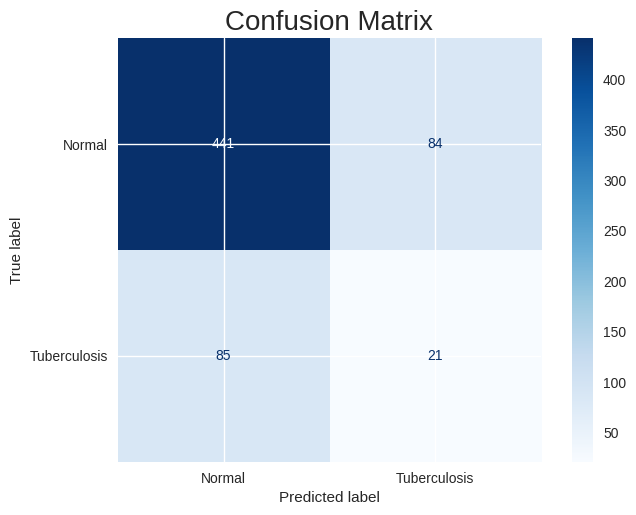

In [15]:
evaluate_model(efficientnet, test_dl)